# 1 · Data preparation

**Dataset:** Figshare brain tumor dataset (Cheng et al., 2017), the same one used in the paper.
3064 **T1-weighted contrast-enhanced MRI** slices from 233 patients. Each file has:
* the MRI image
* the tumour type: meningioma, glioma or pituitary
* a tumour mask drawn by radiologists

The paper classifies tumours as **benign** (meningioma, pituitary) or **malignant** (glioma).
Because we train on a CPU, we use a small subset (`C.IMAGES_PER_CLASS` images per class).

In [1]:
import sys
sys.path.append("..")          # so we can import the src/ folder

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import cv2
from src import config as C
from src.data_utils import download_dataset, convert_to_png, make_splits

C:\Users\DELL\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Step 1 — Download (~880 MB, only the first time)

In [2]:
download_dataset()

dataset already downloaded


## Step 2 — Convert MATLAB `.mat` files to PNG images
MRI scanners store intensities with more than 8 bits, so we rescale each slice to 0–255.

In [3]:
df = convert_to_png()
df.head()

  0%|          | 0/3064 [00:00<?, ?it/s]

  0%|          | 8/3064 [00:00<00:41, 73.73it/s]

  1%|          | 16/3064 [00:00<00:41, 72.79it/s]

  1%|          | 24/3064 [00:00<00:43, 69.50it/s]

  1%|          | 32/3064 [00:00<00:43, 69.82it/s]

...

 99%|█████████▉| 3047/3064 [00:50<00:00, 56.73it/s]

100%|█████████▉| 3053/3064 [00:50<00:00, 56.85it/s]

100%|█████████▉| 3059/3064 [00:50<00:00, 55.94it/s]

100%|██████████| 3064/3064 [00:51<00:00, 60.06it/s]

,file,patient,tumor_type,label,class
0,0001.png,100360,meningioma,0,benign
1,0002.png,100360,meningioma,0,benign
2,0003.png,100360,meningioma,0,benign
3,0004.png,100360,meningioma,0,benign
4,0005.png,100360,meningioma,0,benign


In [4]:
df.groupby(["class", "tumor_type"]).size()

class      tumor_type
benign     meningioma     708
           pituitary      930
malignant  glioma        1426
dtype: int64

## Step 3 — Look at the data

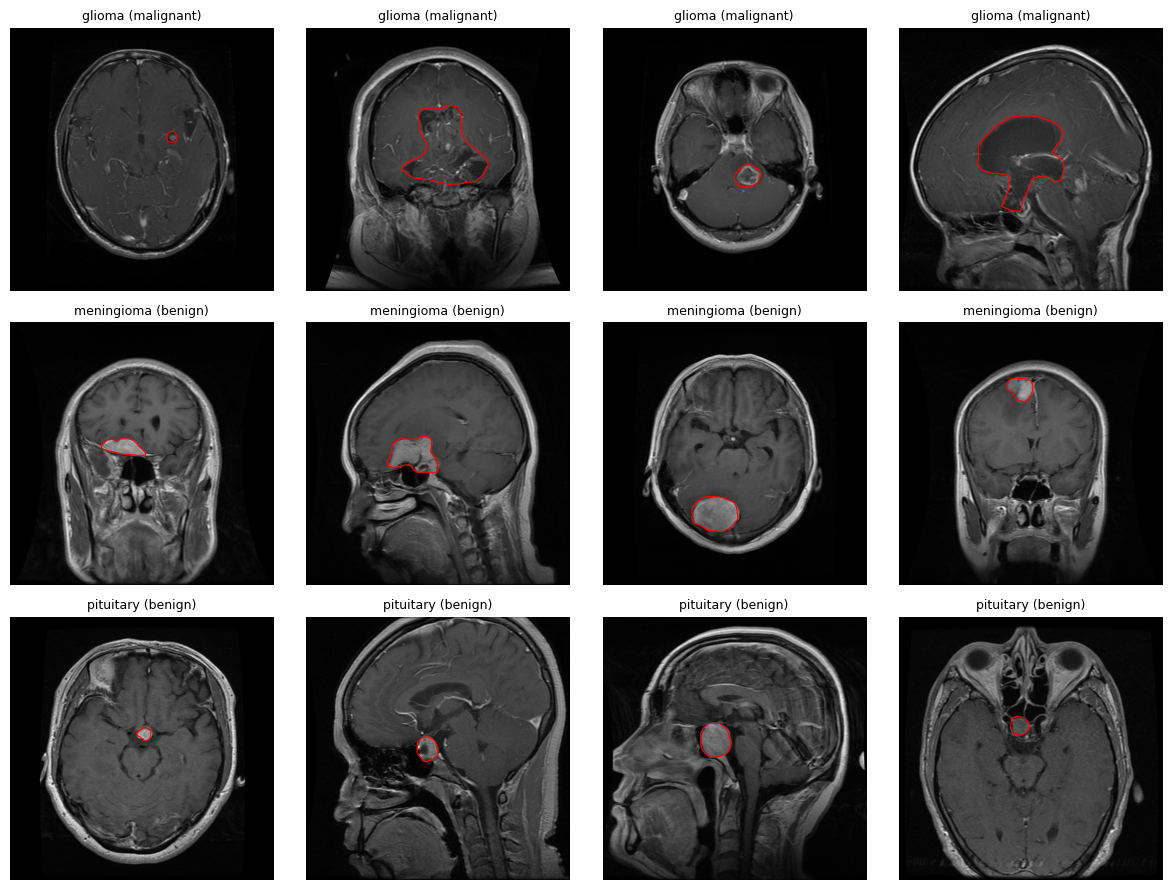

In [5]:
fig, axes = plt.subplots(3, 4, figsize=(12, 9))
for row, (tumor, group) in enumerate(df.groupby("tumor_type")):
    for col, (_, r) in enumerate(group.sample(4, random_state=0).iterrows()):
        img = cv2.imread(str(C.IMAGES_DIR / r.file), 0)
        mask = cv2.imread(str(C.MASKS_DIR / r.file), 0)
        axes[row, col].imshow(img, cmap="gray")
        axes[row, col].contour(mask > 0, colors="red", linewidths=0.8)   # tumour outline
        axes[row, col].set_title(f"{tumor} ({r['class']})", fontsize=9)
        axes[row, col].axis("off")
plt.tight_layout()
plt.savefig(C.RESULTS_DIR / "samples.png", dpi=100)

**Things to notice (medical imaging):**
* slices come in 3 views: **axial** (top-down), **coronal** (front) and **sagittal** (side)
* the tumours look bright because a contrast agent (gadolinium) was injected before the T1 scan
* pituitary tumours sit at the base of the brain; gliomas grow inside the brain tissue; meningiomas start at the brain's outer membrane

## Step 4 — Small subset + train / val / test split **by patient**
One patient has many similar slices. If slices of the same patient were in both train and test,
the model would recognise the patient rather than the tumour, and the test accuracy would look too good.

In [6]:
data = make_splits(df)
pd.crosstab(data.split, data["class"], margins=True)

class,benign,malignant,All
split,,,
test,47,47,94
train,215,213,428
val,39,42,81
All,301,302,603


In [7]:
# check: every patient is in exactly one split
assert data.groupby("patient").split.nunique().max() == 1
print("patients per split:", data.groupby("split").patient.nunique().to_dict())

patients per split: {'test': 20, 'train': 89, 'val': 19}
